In this notebook, we compared trajectories of voxl px4 visual odometry and gps measured by the flights.

In [1]:
import os
import sys
sys.path.append('/app/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
from datetime import datetime
import seaborn as sns
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
from configs.configs import ErrorEnum
from utils.error_report import get_error_from_list, get_error_report
from utils import lla_to_enu, lla_to_ned
from decimal import Decimal, getcontext
import scipy.stats as stats
from numpy.linalg import norm

from ahrs.filters import Madgwick

%matplotlib inline
np.random.seed(777)

In [4]:
root_path = "../../../../"

uav_root_path = os.path.join(root_path, "data/UAV")

vo_log0000_path = os.path.join(uav_root_path, "log0000/px4/13_07_41/13_07_41_vehicle_visual_odometry_0.csv")
vehicle_odometry_log0000_path = os.path.join(uav_root_path, "log0000/px4/13_07_41/13_07_41_vehicle_odometry_0.csv")
gps_log0000_path = os.path.join(uav_root_path, "log0000/px4/13_07_41/13_07_41_sensor_gps_0.csv")

vo_log0001_path = os.path.join(uav_root_path, "log0001/px4/13_13_57_vehicle_visual_odometry_0.csv")
vehicle_odometry_log0001_path = os.path.join(uav_root_path, "log0001/px4/13_13_57_vehicle_odometry_0.csv")
gps_log0001_path = os.path.join(uav_root_path, "log0001/px4/13_13_57_sensor_gps_0.csv")

vo_log0003_path = os.path.join(uav_root_path, "log0003/px4/13_16_27_vehicle_visual_odometry_0.csv")
vehicle_odometry_log0003_path = os.path.join(uav_root_path, "log0003/px4/13_16_27_vehicle_odometry_0.csv")
gps_log0003_path = os.path.join(uav_root_path, "log0003/px4/13_16_27_sensor_gps_0.csv")


In [5]:
# Load log data

vo_df0 = pd.read_csv(vo_log0000_path)
vo_df1 = pd.read_csv(vo_log0001_path)
vo_df3 = pd.read_csv(vo_log0003_path)

v_o_df0 = pd.read_csv(vehicle_odometry_log0000_path)
v_o_df1 = pd.read_csv(vehicle_odometry_log0001_path)
v_o_df3 = pd.read_csv(vehicle_odometry_log0003_path)

gps_df0 = pd.read_csv(gps_log0000_path)
gps_df1 = pd.read_csv(gps_log0001_path)
gps_df3 = pd.read_csv(gps_log0003_path)

In [6]:
# Convert lla(Int) into lla(float)

getcontext().prec = 10
def int2float_lla(x):
    return float(Decimal(x / Decimal(10**(len(str(x)) - 2))))

def int_lla_to_float_lla(df):
    df['lat'] = df['lat'].apply(lambda x: int2float_lla(x))
    df['lon'] = df['lon'].apply(lambda x: int2float_lla(x))
    df['alt'] = df['alt'].apply(lambda x: int2float_lla(x))
    
int_lla_to_float_lla(gps_df0)
int_lla_to_float_lla(gps_df1)
int_lla_to_float_lla(gps_df3)

In [7]:
# Convert lla into North-East-Down coordinate in meter

def get_ned_coord(df):    
    origin = df[['lon', 'lat', 'alt']].iloc[0].values
    ned_pose = lla_to_ned(df[['lon', 'lat', 'alt']].values.T, origin).T
    df = pd.concat([
        df,
        pd.DataFrame(ned_pose, columns=['north', 'east', 'down'])
    ], axis=1)
    return df

gps_df0 = get_ned_coord(gps_df0)
gps_df1 = get_ned_coord(gps_df1)
gps_df3 = get_ned_coord(gps_df3)

In [8]:
# Downsample Vehicle Visual Odometry and Vehicle Odometry data such that sampling rate is equal to the sampling rate of GPS in order to calculate error

def get_indices_by_gps_timestamp(df_timestamp, gps_timestamp):
    return np.argmin(np.abs(df_timestamp - gps_timestamp))

v_o_df0_gps_indices = gps_df0["timestamp"].apply(lambda x: get_indices_by_gps_timestamp(v_o_df0['timestamp'], x))
v_o_df1_gps_indices = gps_df1["timestamp"].apply(lambda x: get_indices_by_gps_timestamp(v_o_df1['timestamp'], x))
v_o_df3_gps_indices = gps_df3["timestamp"].apply(lambda x: get_indices_by_gps_timestamp(v_o_df3['timestamp'], x))

v_o_df0 = v_o_df0.iloc[v_o_df0_gps_indices]
v_o_df1 = v_o_df1.iloc[v_o_df1_gps_indices]
v_o_df3 = v_o_df3.iloc[v_o_df3_gps_indices]

vo_df0_gps_indices = gps_df0["timestamp"].apply(lambda x: get_indices_by_gps_timestamp(vo_df0['timestamp'], x))
vo_df1_gps_indices = gps_df1["timestamp"].apply(lambda x: get_indices_by_gps_timestamp(vo_df1['timestamp'], x))
vo_df3_gps_indices = gps_df3["timestamp"].apply(lambda x: get_indices_by_gps_timestamp(vo_df3['timestamp'], x))

vo_df0 = vo_df0.iloc[vo_df0_gps_indices]
vo_df1 = vo_df1.iloc[vo_df1_gps_indices]
vo_df3 = vo_df3.iloc[vo_df3_gps_indices]

In [9]:
def print_error_report(report, title):
    print(f"----- {title} -----")
    print(f"Mean Absolute Error: {report[ErrorEnum.MAE]}")
    print(f"Root Mean Squared Error: {report[ErrorEnum.RMSE]}")
    print(f"Maximum Error: {report[ErrorEnum.MAX]}")
    print("")

# Visualize trajectories

In [10]:
gps_columns = ['north', 'east', 'down']
vo_columns = ['position[0]', 'position[1]', 'position[2]']

## Log0000

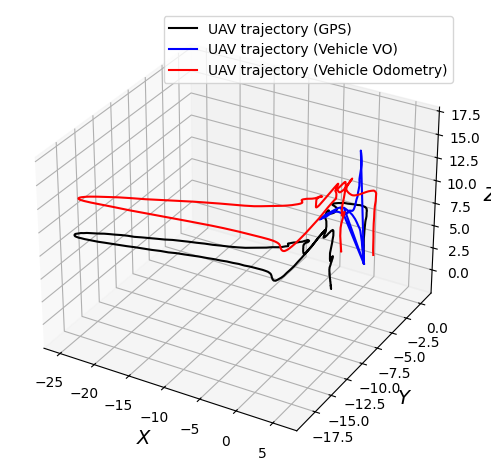

In [11]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
x, y, z = gps_df0[gps_columns].values.T
ax1.plot(x, y, -z, label='UAV trajectory (GPS)', color='black')
x, y, z = vo_df0[vo_columns].values.T
ax1.plot(x, y, -z, label='UAV trajectory (Vehicle VO)', color='blue')
x, y, z = v_o_df0[vo_columns].values.T
ax1.plot(x, y, -z, label='UAV trajectory (Vehicle Odometry)', color='red')
ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)

fig.tight_layout()
plt.show()

In [12]:
print_error_report(
    report=get_error_report(gps_df0[gps_columns].values, vo_df0[vo_columns]),
    title="Deviation between Vehicle Visual Odometry and GPS"
)

print_error_report(
    report=get_error_report(gps_df0[gps_columns].values, v_o_df0[vo_columns]),
    title="Deviation between Vehicle Odometry and GPS"
)

----- Deviation between Vehicle Visual Odometry and GPS -----
Mean Absolute Error: 5.127
Root Mean Squared Error: 7.479
Maximum Error: 25.11

----- Deviation between Vehicle Odometry and GPS -----
Mean Absolute Error: 2.818
Root Mean Squared Error: 3.263
Maximum Error: 6.42



## Log0001

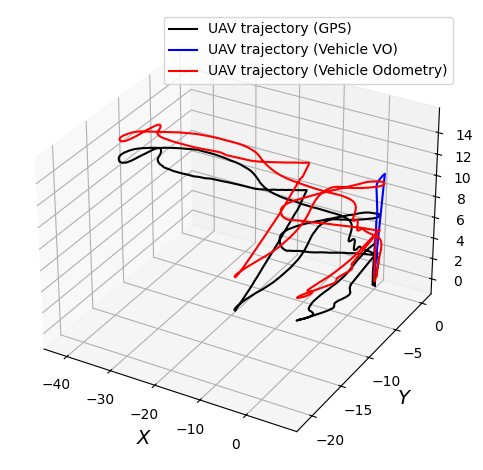

In [13]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
x, y, z = gps_df1[['north', 'east', 'down']].values.T
ax1.plot(x, y, -z, label='UAV trajectory (GPS)', color='black')
x, y, z = vo_df1[['position[0]', 'position[1]', 'position[2]']].values.T
ax1.plot(x, y, -z, label='UAV trajectory (Vehicle VO)', color='blue')
x, y, z = v_o_df1[['position[0]', 'position[1]', 'position[2]']].values.T
ax1.plot(x, y, -z, label='UAV trajectory (Vehicle Odometry)', color='red')
ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)

fig.tight_layout()
plt.show()

In [14]:
print_error_report(
    report=get_error_report(gps_df1[gps_columns].values, vo_df1[vo_columns]),
    title="Deviation between Vehicle Visual Odometry and GPS"
)

print_error_report(
    report=get_error_report(gps_df1[gps_columns].values, v_o_df1[vo_columns]),
    title="Deviation between Vehicle Odometry and GPS"
)

----- Deviation between Vehicle Visual Odometry and GPS -----
Mean Absolute Error: 7.214
Root Mean Squared Error: 10.551
Maximum Error: 41.754

----- Deviation between Vehicle Odometry and GPS -----
Mean Absolute Error: 0.872
Root Mean Squared Error: 1.32
Maximum Error: 3.2



## Log0003

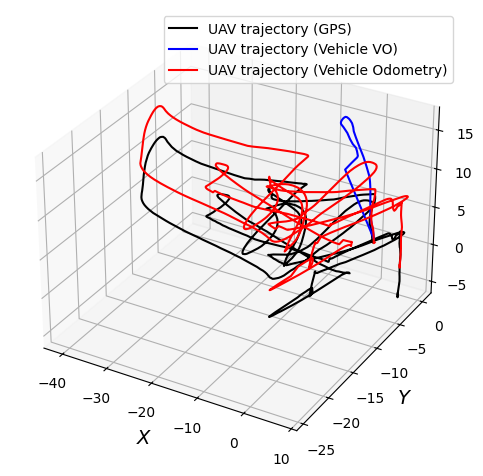

In [15]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
x, y, z = gps_df3[['north', 'east', 'down']].values.T
ax1.plot(x, y, -z, label='UAV trajectory (GPS)', color='black')
x, y, z = vo_df3[['position[0]', 'position[1]', 'position[2]']].values.T
ax1.plot(x, y, -z, label='UAV trajectory (Vehicle VO)', color='blue')
x, y, z = v_o_df3[['position[0]', 'position[1]', 'position[2]']].values.T
ax1.plot(x, y, -z, label='UAV trajectory (Vehicle Odometry)', color='red')
ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)

fig.tight_layout()
plt.show()

In [16]:
print_error_report(
    report=get_error_report(gps_df3[gps_columns].values, vo_df3[vo_columns]),
    title="Deviation between Vehicle Visual Odometry and GPS"
)

print_error_report(
    report=get_error_report(gps_df3[gps_columns].values, v_o_df3[vo_columns]),
    title="Deviation between Vehicle Odometry and GPS"
)

----- Deviation between Vehicle Visual Odometry and GPS -----
Mean Absolute Error: 7.369
Root Mean Squared Error: 10.188
Maximum Error: 40.74

----- Deviation between Vehicle Odometry and GPS -----
Mean Absolute Error: 1.54
Root Mean Squared Error: 2.309
Maximum Error: 5.255



# Conclusion

In this notebook, we investigate the deviation of the position between GPS log measured by PX4 and both Vehicle Visual Odometry and Vehicle Odometry log.
The position estimated by Vehicle Visual Odometry deviates from the GPS position and the phenomenon is observed in every sequences.
The Vehicle Odometry, on the other hand, has less deviation from the GPS position and it keeps track of the trajectory of the aerial vehicle.
From the observation, we can conclude that the positions estimated by the Vehicle Visual Odometry is not reliable when flying outside due to the lack of available feature points captured by horizontally placed stereo camera.